In [46]:
from database.adatabase import ADatabase
import pandas as pd
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
from datetime import datetime, timedelta, timezone
from xgboost import XGBRegressor

In [162]:
db = ADatabase("algo")
market = ADatabase("market")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [165]:
tickers = russell1000["ticker"].values
training_year = datetime.now().year - 3
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
# factors = ["historical_volatility","historical_return","historical_bollinger"]
factors = [str(i) for i in range(5)]

In [179]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["historical_volatility"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["historical_return"] = ticker_prices["adjclose"] / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["historical_bollinger"] = ticker_prices["adjclose"] / (ticker_prices["adjclose"].rolling(100).mean() + 2 * ticker_prices["adjclose"].rolling(100).std()) 
        for i in range(5):
            ticker_prices[str(i)] = ticker_prices["adjclose"].shift(i)
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-5)
        ticker_prices["sell_date"] = ticker_prices["date"] + timedelta(days=7)
        ticker_prices["y"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"]
        prices.append(ticker_prices)
        # training_data = ticker_prices.iloc[100:200]
        # simulation = ticker_prices.iloc[200:]
        # model = XGBRegressor()
        # model.fit(training_data[factors],training_data["y"])
        # simulation["prediction"] = model.predict(simulation[factors])
        # simulation["expected_return"] = (simulation["prediction"] - simulation["adjclose"]) / simulation["adjclose"]
        # if simulation.index.size > 0:
        #     prices.append(simulation)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()
sim = pd.concat(prices).reset_index(drop=True)

model_prep:  18%|█▊        | 178/1009 [00:24<01:30,  9.17it/s]

CAVA [01:20:35] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\data\data.cc:507: Check failed: valid: Label contains NaN, infinity or a value too large.


model_prep:  25%|██▌       | 254/1009 [00:34<01:19,  9.56it/s]

CXT [01:20:45] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\data\data.cc:507: Check failed: valid: Label contains NaN, infinity or a value too large.


model_prep:  30%|██▉       | 300/1009 [00:40<01:17,  9.14it/s]

...

model_prep:  94%|█████████▍| 946/1009 [02:13<00:08,  7.16it/s]

VSTS index 0 is out of bounds for axis 0 with size 0


model_prep:  98%|█████████▊| 990/1009 [02:19<00:02,  8.39it/s]

KLG index 0 is out of bounds for axis 0 with size 0


model_prep: 100%|██████████| 1009/1009 [02:22<00:00,  7.10it/s]


In [180]:
positions = 10
hedge_percentage = 0.05
sim["return"] = (sim["sell_price"] - sim["buy_price"]) / sim ["buy_price"] * (1/positions) * 0.995
sim["return"] = [max(float(-hedge_percentage/positions),x) for x in sim["return"]]
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==weekday].copy()
trades = processor.column_date_processing(trades)

In [181]:
valuation_method = "expected_return"

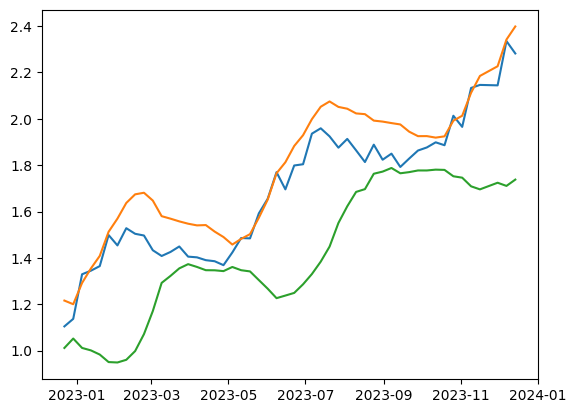

In [182]:
try:
    iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
    portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio = portfolio[(portfolio["date"]<portfolio["date"].max())]
    portfolio["return"] = portfolio["return"] + 1
    portfolio["cumulative_return"] = portfolio["return"].cumprod()
    portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
    portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
    portfolio.dropna(inplace=True)
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["upper"].values)
    plt.plot(portfolio["date"].values,portfolio["lower"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [183]:
iteration_trades.sort_values("return",ascending=False).head(positions)

,index,date,adjclose,ticker,year,quarter,month,week,weekday,historical_volatility,...,3,4,buy_price,buy_date,sell_price,sell_date,y,prediction,predicted_return,return
542,180799,2023-09-28 04:00:00+00:00,45.35,MRTX,2023,3,9,39,3,0.129501,...,41.35,41.00,43.56,2023-09-29 04:00:00+00:00,62.38,2023-10-05 04:00:00+00:00,0.432048,0.366669,-0.991915,0.042989
576,247891,2022-11-17 05:00:00+00:00,5.95,SHC,2022,4,11,46,3,0.435435,...,6.90,7.33,6.02,2022-11-18 05:00:00+00:00,8.15,2022-11-24 05:00:00+00:00,0.353821,0.042375,-0.992878,0.035205
58,4588,2023-01-05 05:00:00+00:00,9.19,AFRM,2023,1,1,1,3,0.371718,...,9.67,9.66,9.06,2023-01-06 05:00:00+00:00,12.20,2023-01-12 05:00:00+00:00,0.346578,0.199612,-0.978279,0.034485
331,205128,2023-05-04 04:00:00+00:00,7.38,PLTR,2023,2,5,18,3,0.105976,...,7.78,7.75,7.41,2023-05-05 04:00:00+00:00,9.88,2023-05-11 04:00:00+00:00,0.333333,0.088284,-0.988037,0.033167
333,180760,2023-08-03 04:00:00+00:00,29.73,MRTX,2023,3,8,31,3,0.120580,...,30.27,29.64,29.46,2023-08-04 04:00:00+00:00,39.20,2023-08-10 04:00:00+00:00,0.330618,0.351911,-0.988163,0.032896
251,4602,2023-01-26 05:00:00+00:00,14.36,AFRM,2023,1,1,4,3,0.294594,...,15.45,14.30,16.24,2023-01-27 05:00:00+00:00,21.14,2023-02-02 05:00:00+00:00,0.301724,0.199612,-0.986099,0.030022
151,205070,2023-02-09 05:00:00+00:00,7.95,PLTR,2023,1,2,6,3,0.094704,...,8.31,8.41,7.51,2023-02-10 05:00:00+00:00,9.71,2023-02-16 05:00:00+00:00,0.292943,0.132956,-0.983276,0.029148
281,256894,2023-11-09 05:00:00+00:00,14.66,TNDM,2023,4,11,45,3,0.223471,...,15.31,15.75,14.28,2023-11-10 05:00:00+00:00,18.40,2023-11-16 05:00:00+00:00,0.288515,0.195003,-0.986698,0.028707
232,4712,2023-07-06 04:00:00+00:00,13.79,AFRM,2023,3,7,27,3,0.189189,...,15.33,15.38,13.65,2023-07-07 04:00:00+00:00,17.45,2023-07-13 04:00:00+00:00,0.278388,0.199612,-0.985525,0.027700
396,214710,2023-01-05 05:00:00+00:00,12.66,PLUG,2023,1,1,1,3,0.301890,...,12.37,12.23,13.41,2023-01-06 05:00:00+00:00,16.79,2023-01-12 05:00:00+00:00,0.252051,0.126976,-0.989970,0.025079


In [184]:
recommendations

,date,sell_date,ticker,adjclose,predicted_return
26,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,CHPT,2.44,-0.970318
201,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,AMBP,3.89,-0.984575
559,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,WBD,11.49,-0.992440
291,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,AGL,12.61,-0.986917
24,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,OLPX,2.42,-0.969708
307,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,PYCR,21.77,-0.987380
222,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,NVCR,13.35,-0.985287
29,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,PLUG,4.41,-0.971207
97,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,AMC,6.07,-0.981149
490,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,CPNG,16.19,-0.991172


In [185]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()